# ROPE Analysis — Region of Practical Equivalence

This notebook demonstrates the **ROPE** (Region of Practical Equivalence) framework
for Bayesian hypothesis testing with the non-paired Beta–Bernoulli model.

## Why ROPE?

The Savage-Dickey Bayes factor tests the **point null** $H_0: \delta = 0$.
With enough data, even a trivially small effect ($\delta = 0.001$) will
reject $H_0$ — the test is *consistent* but not always *useful*.

ROPE replaces the point null with a **practical equivalence region**:

$$
\text{ROPE} = [-\epsilon,\, +\epsilon]
$$

where $\epsilon$ is the smallest effect size we care about (e.g. 2 percentage points).

### Decision rules (Kruschke, 2018)

Compute the 95% HDI (or credible interval) of the posterior for $\Delta = \theta_A - \theta_B$:

| 95% HDI vs ROPE | Decision |
|---|---|
| HDI entirely **outside** ROPE | **Reject** $H_0$ — practically meaningful effect |
| HDI entirely **inside** ROPE | **Accept** $H_0$ — practically equivalent |
| HDI **overlaps** ROPE | **Undecided** — need more data |

### References

1. **Kruschke, J. K.** (2018). Rejecting or accepting parameter values in Bayesian estimation.
   *Advances in Methods and Practices in Psychological Science*, 1(2), 270–280.
2. **Kruschke, J. K.** (2013). Bayesian estimation supersedes the t test.
   *Journal of Experimental Psychology: General*, 142(2), 573–603.
3. **Kruschke, J. K. & Liddell, T. M.** (2018). The Bayesian New Statistics.
   *Psychonomic Bulletin & Review*, 25(1), 178–206.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

from bayesAB.resources.bayes_nonpaired import NonPairedBayesPropTest
from bayesAB.resources.data_schemas import ROPEResult
from bayesAB.utils.utils import simulate_nonpaired_scores

## 1. ROPE via the library

You can also call ``model.decide()`` to get all three frameworks at once.

The ``ROPEResult`` Pydantic class lives in ``bayesAB.resources.data_schemas``.Each model exposes a ``.rope_test()`` method that returns a ``ROPEResult``.

In [ ]:
# Quick demo — the helper is now a library method:
rope_demo = NonPairedBayesPropTest(seed=0).fit(
    np.array([1, 1, 1, 0, 1]), np.array([0, 1, 0, 1, 0])
).rope_test(rope=(-0.05, 0.05))

print(rope_demo.model_dump_json(indent=2))

## 2. Scenario A — Large, clear effect

True rates: $\theta_A = 0.85$, $\theta_B = 0.65$ → $\Delta = 0.20$.
This is well outside any reasonable ROPE.

In [3]:
sim_large = simulate_nonpaired_scores(N=200, theta_A=0.85, theta_B=0.65, seed=42)
model_large = NonPairedBayesPropTest(seed=42, n_samples=50_000).fit(
    sim_large["y_A"], sim_large["y_B"]
)

print(f"True Δ = {sim_large['theta_A'] - sim_large['theta_B']:.2f}")
model_large.print_summary()

True Δ = 0.20
Beta-Bernoulli posterior summary (Non-Paired)
  θ_A ~ Beta(176, 26)  mean=0.8714  [n_A=200, k_A=175]
  θ_B ~ Beta(131, 71)  mean=0.6486  [n_B=200, k_B=130]
  Mean Δ (θ_A − θ_B):  0.2228
  95% CI:              [0.1423, 0.3027]
  P(A > B):            1.0000  (MC)
  P(B > A):            0.0000  (quadrature)
  Verdict:             A wins

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at Δ=0: 1.0000
  Post.  density at Δ=0: 0.0000
  BF_01 (for H0):        10^-5
  BF_10 (against H0):    10^5
  log₁₀(BF_10):          5.2
  → Decisive evidence against H0
  → Decision: Reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 5.85e-06
  P(H1|data): 0.999994

Posterior Predictive p-values
  Statistic                   Observed    p-value   Status
  -------------------------------------------------------
  mean(y_A)                     0.8750      1.000       OK
  mean(y_B)                     0.6500      1.000       OK
  mean(y_A)-mean(y_B) 

## 3. Scenario B — Tiny, negligible effect

True rates: $\theta_A = 0.72$, $\theta_B = 0.70$ → $\Delta = 0.02$.
This sits right at the ROPE boundary — with enough data the models
should be declared practically equivalent.

In [4]:
sim_tiny = simulate_nonpaired_scores(N=500, theta_A=0.72, theta_B=0.70, seed=123)
model_tiny = NonPairedBayesPropTest(seed=42, n_samples=50_000).fit(
    sim_tiny["y_A"], sim_tiny["y_B"]
)

print(f"True Δ = {sim_tiny['theta_A'] - sim_tiny['theta_B']:.2f}")
model_tiny.print_summary()

True Δ = 0.02
Beta-Bernoulli posterior summary (Non-Paired)
  θ_A ~ Beta(353, 149)  mean=0.7033  [n_A=500, k_A=352]
  θ_B ~ Beta(361, 141)  mean=0.7192  [n_B=500, k_B=360]
  Mean Δ (θ_A − θ_B):  -0.0159
  95% CI:              [-0.0719, 0.0400]
  P(A > B):            0.2908  (MC)
  P(B > A):            0.7115  (quadrature)
  Verdict:             B wins

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at Δ=0: 1.0000
  Post.  density at Δ=0: 11.9464
  BF_01 (for H0):        11.95
  BF_10 (against H0):    0.08
  log₁₀(BF_10):          -1.1
  → Strong evidence for H0
  → Decision: Fail to reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 9.23e-01
  P(H1|data): 0.077241

Posterior Predictive p-values
  Statistic                   Observed    p-value   Status
  -------------------------------------------------------
  mean(y_A)                     0.7040      1.000       OK
  mean(y_B)                     0.7200      1.000       OK
  mean(y_A)-me

## 4. Scenario C — True null (no effect)

True rates: $\theta_A = \theta_B = 0.75$ → $\Delta = 0$.
ROPE should confidently accept practical equivalence.

In [5]:
sim_null = simulate_nonpaired_scores(N=300, theta_A=0.75, theta_B=0.75, seed=99)
model_null = NonPairedBayesPropTest(seed=42, n_samples=50_000).fit(
    sim_null["y_A"], sim_null["y_B"]
)

print(f"True Δ = {sim_null['theta_A'] - sim_null['theta_B']:.2f}")
model_null.print_summary()

True Δ = 0.00
Beta-Bernoulli posterior summary (Non-Paired)
  θ_A ~ Beta(221, 81)  mean=0.7319  [n_A=300, k_A=220]
  θ_B ~ Beta(217, 85)  mean=0.7186  [n_B=300, k_B=216]
  Mean Δ (θ_A − θ_B):  0.0133
  95% CI:              [-0.0577, 0.0843]
  P(A > B):            0.6425  (MC)
  P(B > A):            0.3574  (quadrature)
  Verdict:             Tied

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at Δ=0: 1.0000
  Post.  density at Δ=0: 10.2889
  BF_01 (for H0):        10.29
  BF_10 (against H0):    0.10
  log₁₀(BF_10):          -1.0
  → Strong evidence for H0
  → Decision: Fail to reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 9.11e-01
  P(H1|data): 0.088582

Posterior Predictive p-values
  Statistic                   Observed    p-value   Status
  -------------------------------------------------------
  mean(y_A)                     0.7333      1.000       OK
  mean(y_B)                     0.7200      1.000       OK
  mean(y_A)-mean(y_

## 5. ROPE decisions for all three scenarios

We use $\text{ROPE} = [-0.02, +0.02]$ (2 percentage points) — effects smaller
than this are considered negligible.

In [ ]:
ROPE = (-0.02, 0.02)

scenarios = {
    "Large effect (Δ=0.20)": model_large,
    "Tiny effect (Δ=0.02)": model_tiny,
    "True null (Δ=0.00)": model_null,
}

print(f"ROPE = [{ROPE[0]}, {ROPE[1]}]")
print("=" * 90)
print(
    f"{'Scenario':<25} {'95% CI':>20} {'% in ROPE':>10} "
    f"{'% below':>8} {'% above':>8}   {'Decision'}"
)
print("=" * 90)

rope_results = {}
for name, model in scenarios.items():
    r = model.rope_test(rope=ROPE)
    rope_results[name] = r
    print(
        f"{name:<25} [{r.ci_lower:+.4f}, {r.ci_upper:+.4f}] "
        f"{r.pct_in_rope:>9.1%} {r.pct_below_rope:>7.1%} "
        f"{r.pct_above_rope:>7.1%}   {r.decision}"
    )

print("=" * 90)

ROPE = [-0.02, 0.02]
Scenario                                95% CI  % in ROPE  % below  % above   Decision
Large effect (Δ=0.20)     [+0.1423, +0.3027]      0.0%    0.0%  100.0%   Reject H0 — A practically better
Tiny effect (Δ=0.02)      [-0.0719, +0.0400]     45.2%   44.2%   10.6%   Undecided — CI overlaps ROPE
True null (Δ=0.00)        [-0.0577, +0.0843]     39.8%   17.8%   42.5%   Undecided — CI overlaps ROPE


## 6. Visualisation: Posterior + ROPE

For each scenario we plot the posterior density of $\Delta = \theta_A - \theta_B$
with the ROPE shaded and the 95% CI marked.

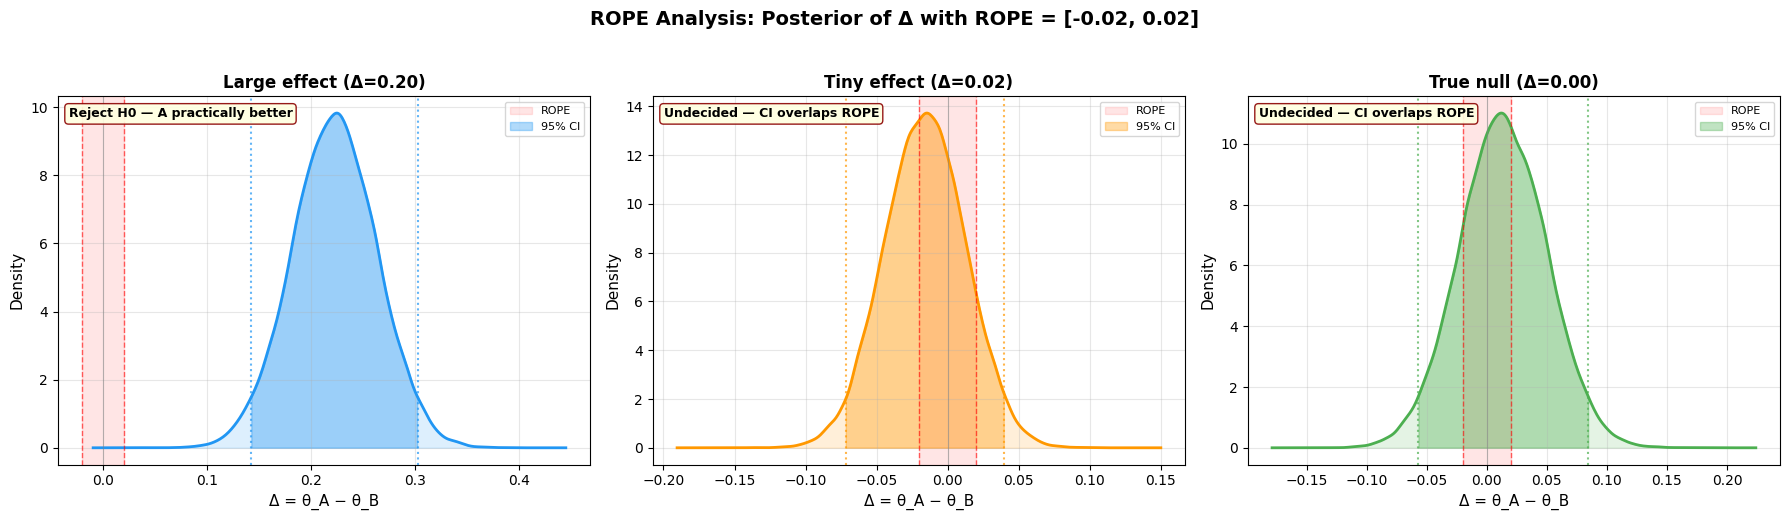

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_list = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (name, model), col in zip(axes, scenarios.items(), colors_list, strict=False):
    samples = model.delta_samples
    r = rope_results[name]

    kde = gaussian_kde(samples)
    x_grid = np.linspace(samples.min() - 0.05, samples.max() + 0.05, 500)
    density = kde(x_grid)

    # Posterior density
    ax.plot(x_grid, density, color=col, linewidth=2)
    ax.fill_between(x_grid, density, alpha=0.15, color=col)

    # ROPE region
    ax.axvspan(ROPE[0], ROPE[1], color="red", alpha=0.10, label="ROPE")
    ax.axvline(ROPE[0], color="red", ls="--", lw=1, alpha=0.6)
    ax.axvline(ROPE[1], color="red", ls="--", lw=1, alpha=0.6)

    # 95% CI
    ci_mask = (x_grid >= r.ci_lower) & (x_grid <= r.ci_upper)
    ax.fill_between(x_grid[ci_mask], density[ci_mask], alpha=0.35, color=col, label="95% CI")
    ax.axvline(r.ci_lower, color=col, ls=":", lw=1.5, alpha=0.7)
    ax.axvline(r.ci_upper, color=col, ls=":", lw=1.5, alpha=0.7)

    # Zero line
    ax.axvline(0, color="gray", ls="-", lw=0.8, alpha=0.5)

    # Decision annotation
    ax.text(
        0.02, 0.97, r.decision,
        transform=ax.transAxes, fontsize=9, fontweight="bold",
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                  edgecolor="darkred", alpha=0.9),
    )

    ax.set_xlabel("Δ = θ_A − θ_B", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

fig.suptitle(
    f"ROPE Analysis: Posterior of Δ with ROPE = [{ROPE[0]}, {ROPE[1]}]",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
plt.show()

## 7. ROPE vs Savage-Dickey — Side-by-side comparison

Compare the ROPE decision with the Savage-Dickey point-null BF for each scenario.
Key insight: when the true effect is tiny but non-zero, Savage-Dickey may still
reject $H_0$ (with enough data), while ROPE correctly classifies the effect as
negligible.

In [ ]:
print(f"{'Scenario':<25} {'ROPE decision':<40} {'BF₁₀':>8} {'SD decision':>20}")
print("=" * 100)

for name, model in scenarios.items():
    r = rope_results[name]
    bf = model.savage_dickey_test()
    print(
        f"{name:<25} {r.decision:<40} "
        f"{bf.BF_10:>8.2f} {bf.decision:>20}"
    )

print("=" * 100)
print("\nNote: Savage-Dickey tests δ = 0 exactly. ROPE tests |δ| ≤ ε.")
print("They can disagree when the true effect is real but negligibly small.")

Scenario                  ROPE decision                                BF₁₀          SD decision
Large effect (Δ=0.20)     Reject H0 — A practically better         170994.06            Reject H0
Tiny effect (Δ=0.02)      Undecided — CI overlaps ROPE                 0.08    Fail to reject H0
True null (Δ=0.00)        Undecided — CI overlaps ROPE                 0.10    Fail to reject H0

Note: Savage-Dickey tests δ = 0 exactly. ROPE tests |δ| ≤ ε.
They can disagree when the true effect is real but negligibly small.


## 8. Sensitivity to ROPE width

How does the decision change as we vary the ROPE half-width $\epsilon$?
For the "tiny effect" scenario this is especially informative —
there will be a critical $\epsilon$ where the decision flips from
"undecided" to "accept".

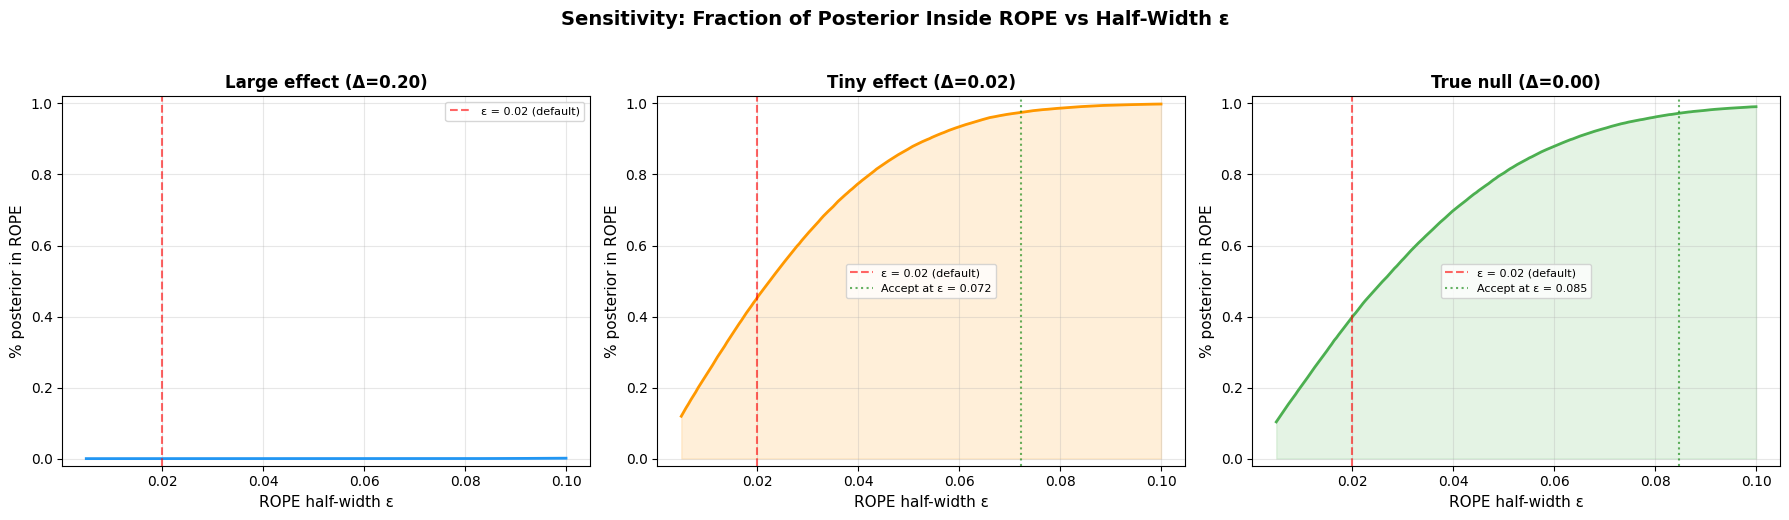

In [ ]:
epsilon_grid = np.linspace(0.005, 0.10, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_list = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (name, model), col in zip(axes, scenarios.items(), colors_list, strict=False):
    samples = model.delta_samples
    pct_in = []
    decisions = []

    for eps in epsilon_grid:
        r = ROPEResult.from_samples(samples, rope=(-eps, eps))
        pct_in.append(r.pct_in_rope)
        decisions.append(r.decision)

    ax.plot(epsilon_grid, pct_in, color=col, linewidth=2)
    ax.fill_between(epsilon_grid, pct_in, alpha=0.15, color=col)

    # Mark default ROPE
    ax.axvline(0.02, color="red", ls="--", lw=1.5, alpha=0.6, label="ε = 0.02 (default)")

    # Find transition points
    for i, d in enumerate(decisions):
        if "Accept" in d:
            ax.axvline(epsilon_grid[i], color="green", ls=":", lw=1.5, alpha=0.6,
                       label=f"Accept at ε = {epsilon_grid[i]:.3f}")
            break

    ax.set_xlabel("ROPE half-width ε", fontsize=11)
    ax.set_ylabel("% posterior in ROPE", fontsize=11)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Sensitivity: Fraction of Posterior Inside ROPE vs Half-Width ε",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
plt.show()

## 9. ROPE with real evaluation data

Apply ROPE analysis to the cached evaluation scores (same data as the
paired Laplace notebook, but treated as non-paired here for illustration).

In [ ]:
from bayesAB.config import global_config as glob
from bayesAB.services.file import JSONService

scores_svc = JSONService(path="eval_scores.json", root_path=glob.DATA_PKG_DIR, verbose=True)
cached = scores_svc.doRead()

if cached:
    metric_names = list(cached["metrics"].keys())
    BINARIZE_THRESHOLD = 0.7
    ROPE_REAL = (-0.02, 0.02)

    print(f"Models: {cached['model_A']} vs {cached['model_B']}")
    print(f"ROPE = {ROPE_REAL}")
    print("=" * 95)
    print(
        f"{'Metric':<25} {'95% CI':>20} {'% in ROPE':>10} "
        f"{'ROPE decision':<35} {'BF₁₀':>8}"
    )
    print("=" * 95)

    real_models = {}
    for metric in metric_names:
        m = cached["metrics"][metric]
        s_A = np.array(m["s_A_raw"])
        s_B = np.array(m["s_B_raw"])
        n = min(len(s_A), len(s_B))

        y_A = (s_A[:n] >= BINARIZE_THRESHOLD).astype(float)
        y_B = (s_B[:n] >= BINARIZE_THRESHOLD).astype(float)

        model = NonPairedBayesPropTest(seed=42, n_samples=50_000).fit(y_A, y_B)
        real_models[metric] = model

        r = model.rope_test(rope=ROPE_REAL)
        bf = model.savage_dickey_test()

        print(
            f"{metric:<25} [{r.ci_lower:+.4f}, {r.ci_upper:+.4f}] "
            f"{r.pct_in_rope:>9.1%} {r.decision:<35} {bf.BF_10:>8.2f}"
        )

    print("=" * 95)
else:
    print("eval_scores.json not found — skipping real data analysis.")
    print("Run eval_dataset_creation.ipynb first to generate the data.")

Read: /Users/avosseler/Github_priv/bayesAB/data/eval_scores.json
Models: gemini-2.5-flash vs gemini-2.0-flash
ROPE = (-0.02, 0.02)
Metric                                  95% CI  % in ROPE ROPE decision                           BF₁₀
Answer Relevancy          [-0.0838, +0.0179]     34.1% Undecided — CI overlaps ROPE            0.13
Faithfulness              [-0.0094, +0.1140]     15.9% Undecided — CI overlaps ROPE            0.29


## 10. Combined forest plot with ROPE

Forest plot showing the posterior mean and 95% CI for each metric,
with the ROPE region highlighted.

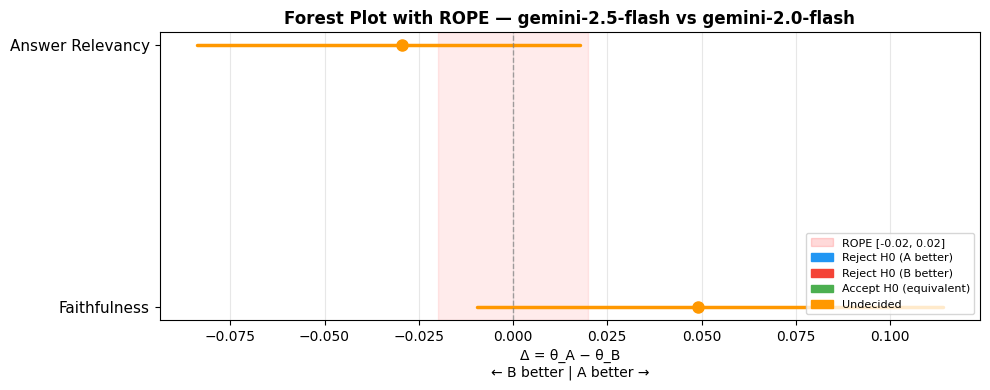

In [ ]:
if cached:
    fig, ax = plt.subplots(figsize=(10, 4))

    metrics = list(real_models.keys())
    y_pos = np.arange(len(metrics))

    # ROPE band
    ax.axvspan(ROPE_REAL[0], ROPE_REAL[1], color="red", alpha=0.08, label="ROPE")

    for i, metric in enumerate(metrics):
        model = real_models[metric]
        r = model.rope_test(rope=ROPE_REAL)

        if "Reject" in r.decision and "A" in r.decision:
            col = "#2196F3"
        elif "Reject" in r.decision and "B" in r.decision:
            col = "#F44336"
        elif "Accept" in r.decision:
            col = "#4CAF50"
        else:
            col = "#FF9800"

        ax.plot(
            [r.ci_lower, r.ci_upper], [i, i],
            color=col, linewidth=2.5, solid_capstyle="round",
        )
        ax.plot(
            model.summary.mean_delta, i, "o",
            color=col, markersize=8, zorder=5,
        )

    ax.axvline(0, color="gray", ls="--", lw=1, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(metrics, fontsize=11)
    ax.set_xlabel("Δ = θ_A − θ_B\n← B better | A better →", fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

    legend_elements = [
        mpatches.Patch(color="red", alpha=0.15, label=f"ROPE [{ROPE_REAL[0]}, {ROPE_REAL[1]}]"),
        mpatches.Patch(color="#2196F3", label="Reject H0 (A better)"),
        mpatches.Patch(color="#F44336", label="Reject H0 (B better)"),
        mpatches.Patch(color="#4CAF50", label="Accept H0 (equivalent)"),
        mpatches.Patch(color="#FF9800", label="Undecided"),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc="lower right")
    ax.set_title(
        f"Forest Plot with ROPE — {cached['model_A']} vs {cached['model_B']}",
        fontsize=12, fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

## Summary

| Framework | Null hypothesis | Decision | Strength |
|---|---|---|---|
| **Savage-Dickey BF** | $\delta = 0$ exactly | Evidence for/against point null | Precise but tests an idealization |
| **ROPE + HDI** | $|\delta| \leq \epsilon$ | Accept / Reject / Undecided | Directly answers "is the effect meaningful?" |
| **P(H₀ \| data)** | $\delta = 0$ (via BF) | Posterior probability of exact null | Interpretable but inherits point-null limitation |

**Recommendation:** Use ROPE when the goal is to decide whether an observed difference
*matters in practice*. Use the Savage-Dickey BF when you need a formal model-comparison
quantity (e.g. for BFDA power analysis). The two complement each other.